<a href="https://colab.research.google.com/github/chaitanya-Dodla/NEURAL-STYLE-TRANSFER/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

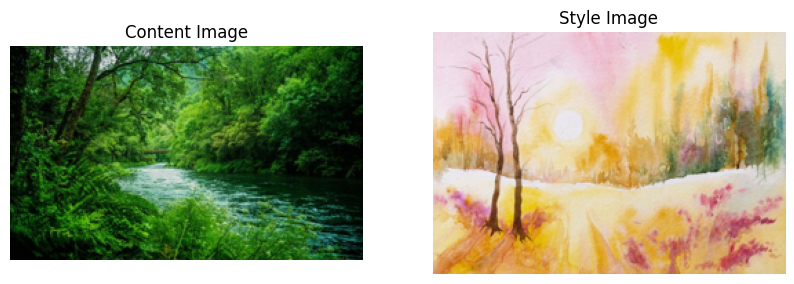

Epoch: 5, Step: 250
Training completed!
Total time: 5.37 seconds


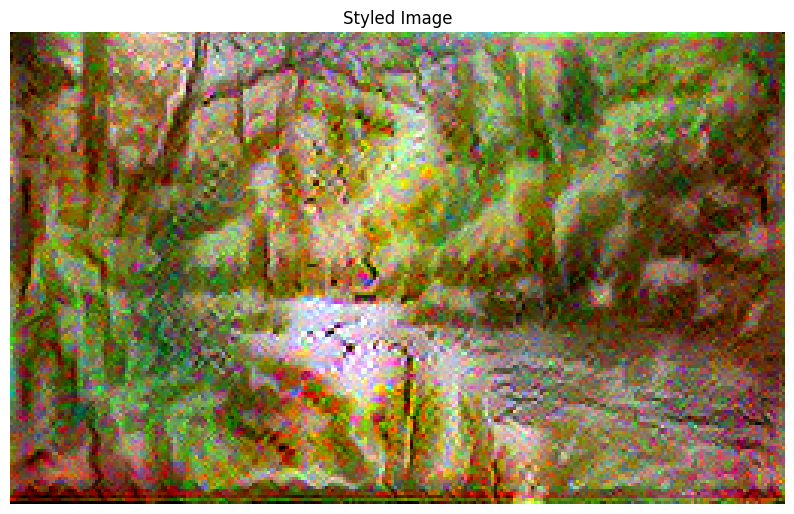


Styled image saved as: styled_output.jpg


In [10]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

# CONFIGURATION

CONTENT_IMAGE_PATH = "content.jpg"
STYLE_IMAGE_PATH = "style.jpg"

OUTPUT_IMAGE = "styled_output.jpg"

# Faster execution
IMAGE_SIZE = 256

EPOCHS = 5
STEPS_PER_EPOCH = 50

CONTENT_WEIGHT = 1e4
STYLE_WEIGHT = 1e-2
TOTAL_VARIATION_WEIGHT = 30

# IMAGE LOADING

def load_img(path_to_img):

    img = Image.open(path_to_img).convert("RGB")

    max_dim = IMAGE_SIZE

    long = max(img.size)

    scale = max_dim / long

    img = img.resize(
        (
            round(img.size[0] * scale),
            round(img.size[1] * scale)
        )
    )

    img = np.array(img)

    img = img.astype(np.float32) / 255.0

    img = tf.convert_to_tensor(img)

    img = img[tf.newaxis, :]

    return img

def imshow(image, title=None):

    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)

    image = tf.clip_by_value(image, 0.0, 1.0)

    plt.imshow(image)

    if title:
        plt.title(title)

    plt.axis('off')

def tensor_to_image(tensor):

    tensor = tf.squeeze(tensor, axis=0)

    tensor = tf.clip_by_value(tensor, 0.0, 1.0)

    tensor = tensor * 255

    tensor = np.array(tensor, dtype=np.uint8)

    return Image.fromarray(tensor)

content_image = load_img(CONTENT_IMAGE_PATH)
style_image = load_img(STYLE_IMAGE_PATH)

# SHOW INPUT IMAGES

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
imshow(content_image, "Content Image")

plt.subplot(1, 2, 2)
imshow(style_image, "Style Image")

plt.show()

# VGG19 MODEL

content_layers = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

vgg = tf.keras.applications.VGG19(
    include_top=False,
    weights='imagenet'
)

vgg.trainable = False

def vgg_layers(layer_names):

    outputs = [vgg.get_layer(name).output for name in layer_names]

    model = tf.keras.Model([vgg.input], outputs)

    return model

# GRAM MATRIX

def gram_matrix(input_tensor):

    result = tf.linalg.einsum(
        'bijc,bijd->bcd',
        input_tensor,
        input_tensor
    )

    input_shape = tf.shape(input_tensor)

    num_locations = tf.cast(
        input_shape[1] * input_shape[2],
        tf.float32
    )

    return result / num_locations

# STYLE CONTENT MODEL

class StyleContentModel(tf.keras.models.Model):

    def __init__(self, style_layers, content_layers):

        super(StyleContentModel, self).__init__()

        self.vgg = vgg_layers(style_layers + content_layers)

        self.style_layers = style_layers

        self.content_layers = content_layers

        self.num_style_layers = len(style_layers)

        self.vgg.trainable = False

    def call(self, inputs):

        inputs = inputs * 255.0

        preprocessed_input = tf.keras.applications.vgg19.preprocess_input(inputs)

        outputs = self.vgg(preprocessed_input)

        style_outputs = outputs[:self.num_style_layers]

        content_outputs = outputs[self.num_style_layers:]

        style_outputs = [
            gram_matrix(style_output)
            for style_output in style_outputs
        ]

        content_dict = {
            content_name: value
            for content_name, value
            in zip(self.content_layers, content_outputs)
        }

        style_dict = {
            style_name: value
            for style_name, value
            in zip(self.style_layers, style_outputs)
        }

        return {
            'content': content_dict,
            'style': style_dict
        }

extractor = StyleContentModel(style_layers, content_layers)

style_targets = extractor(style_image)['style']

content_targets = extractor(content_image)['content']

image = tf.Variable(content_image)

# LOSS FUNCTION

def style_content_loss(outputs):

    style_outputs = outputs['style']

    content_outputs = outputs['content']

    style_loss = tf.add_n([
        tf.reduce_mean(
            (style_outputs[name] - style_targets[name]) ** 2
        )
        for name in style_outputs.keys()
    ])

    style_loss *= STYLE_WEIGHT / num_style_layers

    content_loss = tf.add_n([
        tf.reduce_mean(
            (content_outputs[name] - content_targets[name]) ** 2
        )
        for name in content_outputs.keys()
    ])

    content_loss *= CONTENT_WEIGHT / num_content_layers

    loss = style_loss + content_loss

    return loss

# OPTIMIZER

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.02,
    beta_1=0.99,
    epsilon=1e-1
)

# TRAIN STEP

@tf.function()
def train_step(image):

    with tf.GradientTape() as tape:

        outputs = extractor(image)

        loss = style_content_loss(outputs)

        loss += TOTAL_VARIATION_WEIGHT * tf.image.total_variation(image)

    grad = tape.gradient(loss, image)

    optimizer.apply_gradients([(grad, image)])

    image.assign(
        tf.clip_by_value(image, 0.0, 1.0)
    )


# TRAINING

step = 0

start = time.time()

for n in range(EPOCHS):

    for m in range(STEPS_PER_EPOCH):

        step += 1

        train_step(image)

        print(f"Epoch: {n+1}, Step: {step}", end='\r')

end = time.time()

print("\nTraining completed!")

print(f"Total time: {end - start:.2f} seconds")

# DISPLAY FINAL OUTPUT


plt.figure(figsize=(10,10))

imshow(image, title="Styled Image")

plt.show()

# SAVE OUTPUT

output = tensor_to_image(image)

output.save(OUTPUT_IMAGE)

print(f"\nStyled image saved as: {OUTPUT_IMAGE}")